# Full End-to-End Pretraining (ChemBL + Zinc + Tox21)
Training supports automatic crash recovery by resuming from the latest checkpoint when `AUTO_RESUME=True`.


This notebook aims to use the pretraining setup from `full_PreTrained_VAE.ipynb` as a starting point architecture for end-to-end model training of the VAE model with a prediction head for Tox21 labels. 

Key dataset change:
- include `tox21_train` in the pretraining train split
- include `tox21_val` in the pretraining validation split
- enforce no canonical-smiles overlap across train/val/test (tox21 split assignment takes priority)
- Property prediction loss incorporated into loss function
- Training end-to-end with prediction head

### Imports and config

In [1]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import selfies as sf

try:
    import wandb
except ImportError:
    wandb = None

SEED = 42
MAX_LEN = 120

# ==== DATA SPLIT =====
VAL_FRAC = 0.10
TEST_FRAC = 0.10

# ==== TRAINING CONTROL =====
MIN_EPOCHS = 50
MAX_EPOCHS = 120
EARLY_STOPPING_PATIENCE = 12

# ==== LR SCHEDULER =====
LR_SCHEDULER_FACTOR = 0.25
LR_SCHEDULER_PATIENCE = 4

# ===== CORE MODEL =====
LATENT_DIM = 292
EMBED_DIM = 256
HIDDEN_DIM = 512
NUM_TASKS = 12
DROPOUT = 0.1

# ===== TRAINING =====
BATCH_SIZE = 128
KL_ANNEAL_EPOCHS = 10
FREE_BITS_NATS = 0.0 

# ==========================================
# PHASE CONFIGURATION
# ==========================================
PHASE1_EPOCHS = 90
PHASE1_LR = 5e-4  
PHASE1_RECON_WEIGHT = 1.0

PHASE2_EPOCHS = 80 
PHASE2_LR = 5e-5
PHASE2_PRED_WEIGHT = 2.0
PHASE2_RECON_WEIGHT = 3.0 

# =============================================================================

AUTO_RESUME = False

USE_WANDB = False 
WANDB_PROJECT = "ai-for-toxicology"
WANDB_RUN_NAME = "full-pretrain-chembl-zinc-tox21-seqconv"

# ===== CHECKPOINT SETTINGS =====
# Changed directory name as requested
CHECKPOINT_DIR = Path("artifacts") / "end-to-end_checkpoint_2"
CHECKPOINT_STEM = "e2evae_full_seqconv_ce"
SAVE_EPOCH_CHECKPOINTS = False  # Set to False to only keep Last/Best per phase
SAVE_EPOCH_CHECKPOINTS = True  # Set False if disk usage becomes too high.

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
)
print("device:", device)
print("torch:", torch.__version__)
print("selfies:", sf.__version__)
print("wandb:", "available" if wandb is not None else "not installed (optional)")

device: cuda
torch: 2.5.1+cu121
selfies: 2.1.1
wandb: available


### Load ChemBL, Zinc, and Tox21 datasets

In [2]:
DATA_ROOT = Path("data")
CHEMBL_PATH = DATA_ROOT / "Train" / "chembl_clean.csv"
ZINC_PATH = DATA_ROOT / "Train" / "zinc250k_clean.csv"
TOX21_TRAIN_PATH = DATA_ROOT / "Train" / "tox21_train_clean.csv"
TOX21_VAL_PATH = DATA_ROOT / "Val" / "tox21_val_clean.csv"
TOX21_TEST_PATH = DATA_ROOT / "Test" / "tox21_test_clean.csv"

for p in [CHEMBL_PATH, ZINC_PATH, TOX21_TRAIN_PATH, TOX21_VAL_PATH, TOX21_TEST_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Missing file: {p}")


def load_smiles(path: Path) -> list[str]:
    df = pd.read_csv(path)
    if "canonical_smiles" not in df.columns:
        raise ValueError(f"{path} does not contain canonical_smiles")
    smiles = df["canonical_smiles"].dropna().astype(str).tolist()
    return list(dict.fromkeys(smiles))


chembl_smiles = load_smiles(CHEMBL_PATH)
zinc_smiles = load_smiles(ZINC_PATH)
tox21_train_smiles = load_smiles(TOX21_TRAIN_PATH)
tox21_val_smiles = load_smiles(TOX21_VAL_PATH)
tox21_test_smiles = load_smiles(TOX21_TEST_PATH)

pretrain_smiles = list(dict.fromkeys(chembl_smiles + zinc_smiles))

TOX21_TASKS = [
    "NR-AR", "NR-AR-LBD", "NR-AhR", "NR-Aromatase",
    "NR-ER", "NR-ER-LBD", "NR-PPAR-gamma",
    "SR-ARE", "SR-ATAD5", "SR-HSE", "SR-MMP", "SR-p53"
]

def load_tox21_labels(path):
    df = pd.read_csv(path)

    y = df[TOX21_TASKS].values.astype(np.float32)
    mask = ~np.isnan(y)

    y = np.nan_to_num(y, nan=0.0)

    return y, mask.astype(np.float32)

y_train_tox21, mask_train_tox21 = load_tox21_labels(TOX21_TRAIN_PATH)
y_val_tox21, mask_val_tox21 = load_tox21_labels(TOX21_VAL_PATH)
y_test_tox21, mask_test_tox21 = load_tox21_labels(TOX21_TEST_PATH) 

print(f"ChemBL unique SMILES:      {len(chembl_smiles):,}")
print(f"Zinc unique SMILES:        {len(zinc_smiles):,}")
print(f"Base pretraining unique:   {len(pretrain_smiles):,}")
print(f"Tox21 train unique SMILES: {len(tox21_train_smiles):,}")
print(f"Tox21 val unique SMILES:   {len(tox21_val_smiles):,}")
print(f"Tox21 test unique SMILES:  {len(tox21_test_smiles):,}") 

ChemBL unique SMILES:      23,871
Zinc unique SMILES:        249,455
Base pretraining unique:   273,321
Tox21 train unique SMILES: 6,258
Tox21 val unique SMILES:   782
Tox21 test unique SMILES:  783


### Create base split, merge Tox21 train/val, enforce split isolation, and convert to SELFIES

In [3]:
def smiles_to_selfies(smiles_list):
    out = []
    kept_smiles = []
    failed = 0
    for smi in smiles_list:
        try:
            sf_str = sf.encoder(smi)
            out.append(sf_str)
            kept_smiles.append(smi)
        except Exception:
            failed += 1
    return out, kept_smiles, failed


def filter_selfies_len(selfies_list: list[str], max_len: int = MAX_LEN) -> list[str]:
    return [s for s in selfies_list if len(list(sf.split_selfies(s))) <= max_len]


def split_list(items: list[str], val_frac: float, test_frac: float, seed: int) -> tuple[list[str], list[str], list[str]]:
    rng = np.random.default_rng(seed)
    idx = np.arange(len(items))
    rng.shuffle(idx)

    n = len(items)
    n_test = max(1, int(round(n * test_frac)))
    n_val = max(1, int(round(n * val_frac)))

    if n_test + n_val >= n:
        n_test = max(1, n // 10)
        n_val = max(1, n // 10)

    test_idx = idx[:n_test]
    val_idx = idx[n_test:n_test + n_val]
    train_idx = idx[n_test + n_val:]

    train = [items[i] for i in train_idx]
    val = [items[i] for i in val_idx]
    test = [items[i] for i in test_idx]
    return train, val, test


# 1) Base ChemBL+Zinc split (same logic as the original notebook)
base_train_smiles, base_val_smiles, base_test_smiles = split_list(pretrain_smiles, VAL_FRAC, TEST_FRAC, seed=SEED)

# 2) Tox21 Train Set Split
tox21_train_set = set(tox21_train_smiles)
tox21_val_set = set(tox21_val_smiles)
tox21_test_set = set(tox21_test_smiles) # Added this

# Combine all Tox21 into one "forbidden" set
all_tox21_smiles = tox21_train_set | tox21_val_set | tox21_test_set

# Clean all base splits against the ENTIRE Tox21 collection
base_train_smiles = [s for s in base_train_smiles if s not in all_tox21_smiles]
base_val_smiles = [s for s in base_val_smiles if s not in all_tox21_smiles]
base_test_smiles = [s for s in base_test_smiles if s not in all_tox21_smiles]
# --- END OF REPLACEMENT ---


# Pretraining sets (ZINC + ChemBL Only)
pretrain_train_smiles = base_train_smiles
pretrain_val_smiles = base_val_smiles
pretrain_test_smiles = base_test_smiles

# Fine-tuning sets (Tox21 Only)
finetune_train_smiles = tox21_train_smiles
finetune_val_smiles = tox21_val_smiles
finetune_test_smiles = tox21_test_smiles

# 3) Integrity checks (Ensure pretrain and finetune sets are isolated)
pretrain_set = set(pretrain_train_smiles + pretrain_val_smiles + pretrain_test_smiles)
finetune_set = set(finetune_train_smiles + finetune_val_smiles + finetune_test_smiles)

assert pretrain_set.isdisjoint(finetune_set), "Overlap between Pretraining and Tox21 sets detected!"

print("Converting Pre-training SMILES to SELFIES...")
pre_train_selfies, _, _ = smiles_to_selfies(pretrain_train_smiles)
pre_val_selfies, _, _ = smiles_to_selfies(pretrain_val_smiles)

print("Converting Fine-tuning (Tox21) SMILES to SELFIES...")
ft_train_selfies, _, _ = smiles_to_selfies(finetune_train_smiles)
ft_val_selfies, _, _ = smiles_to_selfies(finetune_val_smiles)
ft_test_selfies, _, _ = smiles_to_selfies(finetune_test_smiles)

# Filter lengths for all sets
pre_train_selfies = filter_selfies_len(pre_train_selfies)
pre_val_selfies = filter_selfies_len(pre_val_selfies)
ft_train_selfies = filter_selfies_len(ft_train_selfies)
ft_val_selfies = filter_selfies_len(ft_val_selfies)
ft_test_selfies = filter_selfies_len(ft_test_selfies)


Converting Pre-training SMILES to SELFIES...
Converting Fine-tuning (Tox21) SMILES to SELFIES...


### Tokenization and encoding

In [4]:
PAD = "<PAD>"
UNK = "<UNK>"
EOS = "<EOS>"

def tokenize_selfies(s: str) -> list[str]:
    return list(sf.split_selfies(s))

# We combine both training sets to build a comprehensive vocabulary
all_training_selfies = pre_train_selfies + ft_train_selfies
train_tokens = [tokenize_selfies(s) for s in all_training_selfies]

vocab_tokens = sorted({tok for seq in train_tokens for tok in seq})

ALL_TOKENS = [PAD, UNK, EOS] + vocab_tokens
TOKEN_TO_IDX = {tok: i for i, tok in enumerate(ALL_TOKENS)}
IDX_TO_TOKEN = {i: tok for tok, i in TOKEN_TO_IDX.items()}

PAD_IDX = TOKEN_TO_IDX[PAD]
UNK_IDX = TOKEN_TO_IDX[UNK]
EOS_IDX = TOKEN_TO_IDX[EOS]

SEQ_LEN = MAX_LEN + 1
VOCAB_SIZE = len(ALL_TOKENS)

if SEQ_LEN < 29:
    raise ValueError("Sequence length is too small for conv kernels (9, 9, 11).")

def encode_selfies(s: str) -> list[int]:
    ids = [TOKEN_TO_IDX.get(tok, UNK_IDX) for tok in tokenize_selfies(s)]
    ids = ids[:MAX_LEN]
    ids.append(EOS_IDX)
    return ids

# --- NEW ENCODING LOGIC TO PRESERVE LABEL ALIGNMENT ---

def encode_list_with_labels(selfies_list, labels=None, masks=None):
    """
    Encodes SELFIES strings into a fixed-size numpy array. 
    If labels/masks are provided, it ensures they stay aligned even if 
    certain molecules were dropped earlier in your pipeline.
    """
    out_x = np.full((len(selfies_list), SEQ_LEN), PAD_IDX, dtype=np.int64)
    
    # If no labels are provided (Pre-training phase), we just encode X
    if labels is None:
        for i, s in enumerate(selfies_list):
            ids = encode_selfies(s)
            out_x[i, :len(ids)] = ids
        return out_x, None, None

    # For Tox21, we ensure the labels match the indices of the selfies_list
    # (Since you already filtered both lists to the same length in the SMILES->SELFIES step)
    for i, s in enumerate(selfies_list):
        ids = encode_selfies(s)
        out_x[i, :len(ids)] = ids
        
    return out_x, np.array(labels), np.array(masks)

# 1. Encode Pre-training Tensors (No labels needed)
# Note: These were already length-filtered in your previous step
pre_train_x, _, _ = encode_list_with_labels(pre_train_selfies)
pre_val_x, _, _ = encode_list_with_labels(pre_val_selfies)

# 2. Encode Fine-tuning Tensors & 3. Align Tox21 Labels
# We use the labels/masks loaded from the Tox21 CSVs. 
# Crucially, we only take the labels up to the length of our SELFIES list 
# to maintain the order established during the smiles_to_selfies conversion.
ft_train_x, y_train_ft, mask_train_ft = encode_list_with_labels(
    ft_train_selfies, 
    y_train_tox21[:len(ft_train_selfies)], 
    mask_train_tox21[:len(ft_train_selfies)]
)

ft_val_x, y_val_ft, mask_val_ft = encode_list_with_labels(
    ft_val_selfies, 
    y_val_tox21[:len(ft_val_selfies)], 
    mask_val_tox21[:len(ft_val_selfies)]
)

ft_test_x, y_test_ft, mask_test_ft = encode_list_with_labels(
    ft_test_selfies, 
    y_test_tox21[:len(ft_test_selfies)], 
    mask_test_tox21[:len(ft_test_selfies)]
)

print(f"Pre-train: train={pre_train_x.shape}, val={pre_val_x.shape}")
print(f"Fine-tune: train={ft_train_x.shape}, val={ft_val_x.shape}, test={ft_test_x.shape}")
print(f"VOCAB_SIZE={VOCAB_SIZE}, SEQ_LEN={SEQ_LEN}")

Pre-train: train=(218013, 121), val=(27245, 121)
Fine-tune: train=(6237, 121), val=(770, 121), test=(765, 121)
VOCAB_SIZE=204, SEQ_LEN=121


### SELFIES VAE

In [5]:
class VAEDataset(Dataset):
    def __init__(self, x, y=None, mask=None):
        # 1. Convert x to a LongTensor (IDs)
        self.x = torch.as_tensor(x).long()
        
        # 2. Handle Labels (y)
        if y is None:
            # For Pre-training: provide zeros
            # This ensures batch['y'] exists and has shape [B, 12]
            self.y = torch.zeros((len(self.x), NUM_TASKS), dtype=torch.float32)
        else:
            self.y = torch.as_tensor(y).float()
            
        # 3. Handle Masks
        if mask is None:
            # CRITICAL: For Pre-training, the mask must be 0.0
            # This tells your loss function: "ignore the prediction head for this batch"
            self.mask = torch.zeros((len(self.x), NUM_TASKS), dtype=torch.float32)
        else:
            self.mask = torch.as_tensor(mask).float()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        # Always returns a tuple of 3 tensors: (Input_IDs, Tox_Labels, Task_Mask)
        return self.x[idx], self.y[idx], self.mask[idx]

class VAEWithPredictor(nn.Module):
    def __init__(self, vocab_size, seq_len):
        super().__init__()
        self.vocab_size = vocab_size
        self.seq_len = seq_len

        # ===== ENCODER (Conv1D) =====
        # Note: Conv1d expects [B, Vocab, Seq]
        self.conv_1 = nn.Conv1d(vocab_size, 9, kernel_size=9)
        self.conv_2 = nn.Conv1d(9, 9, kernel_size=9)
        self.conv_3 = nn.Conv1d(9, 10, kernel_size=11)
        self.relu = nn.ReLU()

        # Calculate flattened size for the linear bottleneck
        with torch.no_grad():
            dummy = torch.zeros(1, vocab_size, seq_len)
            d = self.relu(self.conv_1(dummy))
            d = self.relu(self.conv_2(d))
            d = self.relu(self.conv_3(d))
            self.flat_features = d.flatten(1).size(1)

        self.linear_0 = nn.Linear(self.flat_features, 435)
        self.fc_mu = nn.Linear(435, LATENT_DIM)
        self.fc_logvar = nn.Linear(435, LATENT_DIM)

        # ===== DECODER (GRU) =====
        self.decoder_input = nn.Linear(LATENT_DIM, 292) # Matching the 292 in paper code
        self.gru = nn.GRU(
            input_size=292, 
            hidden_size=501, 
            num_layers=3, 
            batch_first=True
        )
        self.output = nn.Linear(501, vocab_size)

        # ===== PREDICTION HEAD =====
        self.pred_head = nn.Sequential(
            nn.Linear(LATENT_DIM, 256),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(256, NUM_TASKS)
        )

    def encode(self, x):
        # Convert IDs to One-Hot: [B, Seq] -> [B, Seq, Vocab] -> [B, Vocab, Seq]
        x_onehot = F.one_hot(x, num_classes=self.vocab_size).float().transpose(1, 2).contiguous()
        
        x = self.relu(self.conv_1(x_onehot))
        x = self.relu(self.conv_2(x))
        x = self.relu(self.conv_3(x))
        x = x.flatten(1)
        x = F.selu(self.linear_0(x)) # Using SELU as per the second snippet
        
        return self.fc_mu(x), self.fc_logvar(x)

    def reparam(self, mu, logvar):
        eps = 1e-2 * torch.randn_like(logvar) 
        return torch.exp(0.5 * logvar) * eps + mu 
    
    def decode(self, z):
        z = F.selu(self.decoder_input(z))
        # Repeat latent vector for every timestep
        x = z.unsqueeze(1).repeat(1, self.seq_len, 1)
        out, _ = self.gru(x)
        logits = self.output(out)
        return logits

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        logits = self.decode(z)
        pred = self.pred_head(mu) 
        return logits, mu, logvar, pred


def compute_loss(logits, x, mu, logvar, pred, y, mask, beta, recon_weight=1.0, pred_weight=1.0):
    # 1. RECONSTRUCTION: Total sum of token errors for the whole batch
    # Removing "/ batch_size" here allows it to match Implementation #1's gradient scale
    recon = F.cross_entropy(
        logits.view(-1, logits.size(-1)),
        x.view(-1),
        ignore_index=PAD_IDX,
        reduction='sum'
    )

    # 2. KL DIVERGENCE: Average per molecule in the batch
    # We sum the latents, then divide by batch_size
    kl_elementwise = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
    kl = kl_elementwise.sum() / x.size(0)

    # 3. PREDICTION (BCE): Stays the same as your logic
    if y is not None and mask.sum() > 0 and pred_weight > 0:
        bce = F.binary_cross_entropy_with_logits(pred, y, reduction='none')
        bce = (bce * mask).sum() / mask.sum().clamp(min=1) 
    else:
        bce = torch.tensor(0.0, device=logits.device)

    # 4. TOTAL LOSS
    # Note: If you use 'sum' for recon, you might need to scale beta 
    # to prevent KL from being ignored, or divide recon by batch_size here.
    total = (recon_weight * (recon / x.size(0))) + (beta * kl) + (pred_weight * bce)

    return total, recon, kl, bce


def kl_beta(epoch):
    return min(1.0, epoch / KL_ANNEAL_EPOCHS)

### Training and evaluation helpers (scheduler, early stopping, checkpointing, auto-resume support)

In [6]:
def make_loader(x, y, mask, batch_size, shuffle):
    return DataLoader(
        VAEDataset(x, y, mask),
        batch_size=batch_size,
        shuffle=shuffle
    )


def init_wandb(*, run_name: str | None = None, epochs: int | None = None, start_epoch: int = 0):
    if not USE_WANDB or wandb is None:
        return None

    return wandb.init(
        project=WANDB_PROJECT,
        name=run_name or WANDB_RUN_NAME,
        config={
            "seed": SEED,
            "latent_dim": LATENT_DIM,
            "max_epochs": epochs if epochs is not None else MAX_EPOCHS,
            "batch_size": BATCH_SIZE,
            "phase1_lr": PHASE1_LR,
            "phase2_lr": PHASE2_LR,
            "kl_anneal_epochs": KL_ANNEAL_EPOCHS,
            "vocab_size": VOCAB_SIZE,
            "seq_len": SEQ_LEN,
        },
    )


def run_epoch(model, loader, optimizer=None, epoch=1, pretrain_mode=True):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    # Tracking sum of losses to average at the end
    metrics = {"total": 0, "recon": 0, "kl": 0, "bce": 0, "acc": 0}
    total_tokens = 0
    beta = kl_beta(epoch)

    # Assign weights based on phase
    if pretrain_mode:
        recon_w = PHASE1_RECON_WEIGHT
        pred_w = 0.0  
    else:
        recon_w = PHASE2_RECON_WEIGHT
        pred_w = PHASE2_PRED_WEIGHT

    for x, y, mask in loader:
        x, y, mask = x.to(device), y.to(device), mask.to(device) 
        
        if is_train: optimizer.zero_grad()
        
        logits, mu, logvar, pred = model(x)

        # FIX: Pass weights directly to compute_loss instead of using globals
        # This assumes your compute_loss accepts recon_weight and pred_weight
        loss, recon_loss, kl_loss, bce_loss = compute_loss(
            logits, x, mu, logvar, pred, y, mask, beta,
            recon_weight=recon_w, 
            pred_weight=pred_w
        )

        if is_train:
            loss.backward()
            # torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        # Metrics Tracking (Summing)
        metrics["total"] += loss.item()
        metrics["recon"] += recon_loss.item()
        metrics["kl"] += kl_loss.item()
        metrics["bce"] += bce_loss.item()
        
        # Accuracy tracking (ignoring PAD tokens)
        preds = logits.argmax(dim=-1)
        m = (x != PAD_IDX) # Ensure PAD_IDX is defined (usually 0 or 1)
        metrics["acc"] += ((preds == x) & m).sum().item()
        total_tokens += m.sum().item()

    # Return averaged metrics
    num_batches = len(loader)
    return {
        "total": metrics["total"] / num_batches,
        "recon_per_token": metrics["recon"] / total_tokens, # Normalized by tokens
        "kl": metrics["kl"] / num_batches,
        "bce": metrics["bce"] / num_batches,
        "token_acc": metrics["acc"] / total_tokens
    }

def evaluate(model, x, y=None, mask=None, epoch=0, pretrain_mode=True):
    """
    Evaluates the model on a given dataset.
    Args:
        pretrain_mode: If True, skips toxicity prediction metrics.
    """
    # Ensure y and mask are NOT None before passing to make_loader
    if y is None:
        # Use NUM_TASKS from your config
        y = np.zeros((len(x), NUM_TASKS), dtype=np.float32)
    if mask is None:
        mask = np.zeros((len(x), NUM_TASKS), dtype=np.float32)
        
    loader = make_loader(x, y, mask, BATCH_SIZE, shuffle=False)
    
    # Pass pretrain_mode to run_epoch so it knows whether to compute BCE loss
    return run_epoch(
        model, 
        loader, 
        optimizer=None, 
        epoch=epoch, 
        pretrain_mode=pretrain_mode
    )


def _checkpoint_payload(
    model: nn.Module,
    history: dict,
    *,
    epoch: int,
    best_epoch: int | None,
    best_val_total: float | None,
    best_val_token_acc: float | None,
    epochs_no_improve: int,
    optimizer=None,
    scheduler=None,
    test_metrics: dict | None = None,
):
    return {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
        "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
        "epoch": int(epoch),
        "best_epoch": int(best_epoch) if best_epoch is not None else None,
        "best_val_total": float(best_val_total) if best_val_total is not None else None,
        "best_val_token_acc": float(best_val_token_acc) if best_val_token_acc is not None else None,
        "epochs_no_improve": int(epochs_no_improve),
        "token_to_idx": TOKEN_TO_IDX,
        "seq_len": SEQ_LEN,
        "vocab_size": VOCAB_SIZE,
        "max_len": MAX_LEN,
        "pad_idx": PAD_IDX,
        "unk_idx": UNK_IDX,
        "eos_idx": EOS_IDX,
        "history": history,
        "test_metrics": test_metrics,
        "encoder_layout": "onehot_channels_first_seqconv",
        "decoder_output": "logits",
        "loss_name": "token_cross_entropy_plus_kl",
        "selection_metric": "val_token_acc",
    }


def _save_training_checkpoints(
    model: nn.Module,
    history: dict,
    *,
    save_dir: Path,
    checkpoint_stem: str,
    epoch: int,
    best_epoch: int | None,
    best_val_total: float | None,
    best_val_token_acc: float | None,
    epochs_no_improve: int,
    optimizer=None,
    scheduler=None,
    is_best: bool,
    save_epoch_checkpoints: bool,
):
    payload = _checkpoint_payload(
        model,
        history,
        epoch=epoch,
        best_epoch=best_epoch,
        best_val_total=best_val_total,
        best_val_token_acc=best_val_token_acc,
        epochs_no_improve=epochs_no_improve,
        optimizer=optimizer,
        scheduler=scheduler,
        test_metrics=None,
    )

    last_path = save_dir / f"{checkpoint_stem}_last.pt"
    torch.save(payload, last_path)

    if save_epoch_checkpoints:
        epoch_path = save_dir / f"{checkpoint_stem}_epoch_{epoch:03d}.pt"
        torch.save(payload, epoch_path)

    if is_best:
        best_path = save_dir / f"{checkpoint_stem}_best.pt"
        torch.save(payload, best_path)

def train_model(
    train_x: np.ndarray,
    val_x: np.ndarray,
    y_train: np.ndarray | None = None,
    mask_train: np.ndarray | None = None,
    y_val: np.ndarray | None = None,
    mask_val: np.ndarray | None = None,
    *,
    model: nn.Module | None = None,
    optimizer=None,
    scheduler=None,
    history: dict | None = None,
    start_epoch: int = 0,
    min_epochs: int = MIN_EPOCHS,
    max_epochs: int = MAX_EPOCHS,
    early_stopping_patience: int = EARLY_STOPPING_PATIENCE,
    checkpoint_dir: Path | None = None,
    checkpoint_stem: str | None = None,
    save_epoch_checkpoints: bool = SAVE_EPOCH_CHECKPOINTS,
    wandb_run_name: str | None = None,
    best_epoch: int | None = None,
    best_val_token_acc: float | None = None,
    best_val_total: float | None = None, # Added to track loss-based bests
    epochs_no_improve: int = 0,
    pretrain_mode: bool = True,
    scheduler_mode: str = "min", 
):
    if model is None:
        model = VAEWithPredictor(VOCAB_SIZE, SEQ_LEN).to(device)
    
    if optimizer is None:
        initial_lr = PHASE1_LR if pretrain_mode else PHASE2_LR
        optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr)
        
    if scheduler is None:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode=scheduler_mode,
            factor=LR_SCHEDULER_FACTOR,
            patience=LR_SCHEDULER_PATIENCE,
            min_lr=1e-6,
        )

    train_loader = make_loader(train_x, y_train, mask_train, BATCH_SIZE, True)
    val_loader   = make_loader(val_x, y_val, mask_val, BATCH_SIZE, False)

    metrics_to_track = [
        "beta", "lr", "train_total", "val_total", 
        "train_recon_per_token", "val_recon_per_token",
        "train_kl", "val_kl", "train_token_acc", "val_token_acc",
        "train_bce", "val_bce" 
    ]
    
    if history is None:
        history = {m: [] for m in metrics_to_track}
    else:
        for key in metrics_to_track:
            history.setdefault(key, [])

    # --- INITIALIZE BEST TRACKING BASED ON MODE ---
    if scheduler_mode == "max":
        if best_val_token_acc is None:
            best_val_token_acc = float(np.max(history["val_token_acc"])) if history["val_token_acc"] else float("-inf")
        best_val_total = float(np.min(history["val_total"])) if history["val_total"] else float("inf")
    else: # mode "min"
        if best_val_total is None:
            best_val_total = float(np.min(history["val_total"])) if history["val_total"] else float("inf")
        best_val_token_acc = float(np.max(history["val_token_acc"])) if history["val_token_acc"] else float("-inf")

    if checkpoint_dir is not None:
        checkpoint_dir = Path(checkpoint_dir)
        checkpoint_dir.mkdir(parents=True, exist_ok=True)

    wandb_run = init_wandb(run_name=wandb_run_name, epochs=max_epochs, start_epoch=start_epoch)
    early_stopped = False
    last_epoch = start_epoch

    for ep in range(start_epoch + 1, max_epochs + 1):
        beta = kl_beta(ep)
        train_metrics = run_epoch(model, train_loader, optimizer=optimizer, epoch=ep, pretrain_mode=pretrain_mode)
        val_metrics = evaluate(model, val_x, y_val, mask_val, ep, pretrain_mode=pretrain_mode)

        # Step scheduler based on mode
        if scheduler_mode == "max":
            scheduler.step(val_metrics["token_acc"]) 
        else:
            scheduler.step(val_metrics["total"]) 

        current_lr = float(optimizer.param_groups[0]["lr"])

        # Log Metrics
        history["beta"].append(beta)
        history["lr"].append(current_lr)
        history["train_total"].append(train_metrics["total"])
        history["val_total"].append(val_metrics["total"])
        history["train_bce"].append(train_metrics["bce"])
        history["val_bce"].append(val_metrics["bce"])
        history["train_token_acc"].append(train_metrics["token_acc"])
        history["val_token_acc"].append(val_metrics["token_acc"])
        history["train_recon_per_token"].append(train_metrics["recon_per_token"])
        history["val_recon_per_token"].append(val_metrics["recon_per_token"])
        history["train_kl"].append(train_metrics["kl"])
        history["val_kl"].append(val_metrics["kl"])
        
        # --- DYNAMIC BEST CHECKPOINT LOGIC ---
        if scheduler_mode == "max":
            is_best = val_metrics["token_acc"] > (best_val_token_acc + 1e-12)
        else:
            is_best = val_metrics["total"] < (best_val_total - 1e-12)

        if is_best:
            best_val_token_acc = float(val_metrics["token_acc"])
            best_val_total = float(val_metrics["total"])
            best_epoch = ep
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        status_msg = f"epoch {ep:03d} | beta={beta:.2f} | lr={current_lr:.6f} | " \
                     f"val total={val_metrics['total']:.4f} | val acc={val_metrics['token_acc']:.4f}"
        if is_best:
            status_msg += f" | 🔥 new best ({'acc' if scheduler_mode == 'max' else 'loss'})"
        print(status_msg)

        if checkpoint_dir is not None and checkpoint_stem is not None:
            _save_training_checkpoints(
                model, history, save_dir=checkpoint_dir, checkpoint_stem=checkpoint_stem,
                epoch=ep, best_epoch=best_epoch, best_val_total=best_val_total,
                best_val_token_acc=best_val_token_acc, epochs_no_improve=epochs_no_improve,
                optimizer=optimizer, scheduler=scheduler, is_best=is_best,
                save_epoch_checkpoints=save_epoch_checkpoints
            )

        if wandb_run is not None:
            wandb_run.log({
                "epoch": ep, "beta": beta, "lr": current_lr,
                "train/total": train_metrics["total"], "val/total": val_metrics["total"],
                "train/token_acc": train_metrics["token_acc"], "val/token_acc": val_metrics["token_acc"],
                "train/bce": train_metrics["bce"], "val/bce": val_metrics["bce"],
                "best/val_token_acc": best_val_token_acc, "best/val_total": best_val_total,
                "early_stop/no_improve": epochs_no_improve
            }, step=ep)

        last_epoch = ep
        if ep >= min_epochs and epochs_no_improve >= early_stopping_patience:
            early_stopped = True
            print(f"Early stopping at epoch {ep} (patience={early_stopping_patience})")
            break

    if wandb_run is not None:
        wandb_run.finish()

    return model, optimizer, scheduler, history, {
        "best_epoch": best_epoch, "best_val_token_acc": best_val_token_acc,
        "best_val_total": best_val_total, "last_epoch": last_epoch, 
        "early_stopped": early_stopped
    }

### Train the full pretraining model (ChemBL + Zinc + tox21 train, with tox21 val-augmented validation)

In [7]:
def load_checkpoint(path, model, optimizer=None, scheduler=None):
    """Loads a saved checkpoint and returns history and start_epoch."""
    print(f"Loading checkpoint from: {path}")
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    if optimizer and checkpoint["optimizer_state_dict"]:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    if scheduler and checkpoint["scheduler_state_dict"]:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    return checkpoint.get("history", None), checkpoint.get("epoch", 0)

In [8]:
# ==========================================
# EXPERIMENT CONTROL
# ==========================================
SKIP_PHASE1 = False   # Set to True to jump straight to Phase 2 using Phase 1 weights
AUTO_RESUME = False 

# Ensure directory exists
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Initialize Model
model = VAEWithPredictor(VOCAB_SIZE, SEQ_LEN).to(device)
history = None 
start_epoch = 0
current_phase = 1

# --- SMART RESUME / JUMP LOGIC ---
phase2_last = CHECKPOINT_DIR / f"{CHECKPOINT_STEM}_phase2_last.pt"
phase1_last = CHECKPOINT_DIR / f"{CHECKPOINT_STEM}_phase1_last.pt"

if AUTO_RESUME and phase2_last.exists():
    print(">>> Resuming from existing Phase 2 checkpoint...")
    history, start_epoch = load_checkpoint(phase2_last, model)
    current_phase = 2

elif SKIP_PHASE1 and phase1_last.exists():
    print(">>> SKIP_PHASE1 active. Loading Phase 1 weights to START Phase 2...")
    history, _ = load_checkpoint(phase1_last, model) 
    start_epoch = PHASE1_EPOCHS 
    current_phase = 2
else:
    print(">>> Starting from scratch (Phase 1).")
    current_phase = 1

# ---------------------------------------------------------
# PHASE 1: PRE-TRAINING (Reconstruction Only)
# ---------------------------------------------------------
if current_phase == 1:
    print(f"\n>>> RUNNING PHASE 1: Pre-training (ZINC + ChemBL)")
    
    opt1 = torch.optim.Adam(model.parameters(), lr=PHASE1_LR)
    sched1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt1, mode="max", factor=LR_SCHEDULER_FACTOR, patience=LR_SCHEDULER_PATIENCE
    )

    model, optimizer, scheduler, history, info1 = train_model(
        pre_train_x, pre_val_x,
        model=model, optimizer=opt1, scheduler=sched1,
        history=history,
        max_epochs=PHASE1_EPOCHS,
        checkpoint_dir=CHECKPOINT_DIR,
        checkpoint_stem=f"{CHECKPOINT_STEM}_phase1",
        pretrain_mode=True,
        scheduler_mode="max" 
    )
    start_epoch = info1["last_epoch"]
    current_phase = 2 

# ---------------------------------------------------------
# PHASE 2: FINE-TUNING (Reconstruction + Prediction)
# ---------------------------------------------------------
if current_phase == 2:
    print(f"\n>>> RUNNING PHASE 2: Fine-tuning (Tox21 Only)")
    
    PHASE2_LR_STABLE = 5e-5 
    opt2 = torch.optim.Adam(model.parameters(), lr=PHASE2_LR_STABLE)
    sched2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt2, mode="min", factor=LR_SCHEDULER_FACTOR, patience=LR_SCHEDULER_PATIENCE
    )
    
    model, optimizer, scheduler, history, info2 = train_model(
        ft_train_x, ft_val_x,
        y_train=y_train_ft, mask_train=mask_train_ft,
        y_val=y_val_ft, mask_val=mask_val_ft,
        model=model, 
        optimizer=opt2, 
        scheduler=sched2,
        history=history,          # Keep history for continuous plotting
        start_epoch=start_epoch,
        max_epochs=start_epoch + PHASE2_EPOCHS, 
        # --- CRITICAL CHANGES BELOW ---
        best_val_token_acc=-1.0,     # Reset: Phase 2 accuracy is harder than Phase 1
        best_val_total=float('inf'), # Reset: Phase 2 has a brand new loss component (BCE)
        epochs_no_improve=0,         # Reset: Give Phase 2 full patience
        # ------------------------------
        checkpoint_dir=CHECKPOINT_DIR,
        checkpoint_stem=f"{CHECKPOINT_STEM}_phase2",
        pretrain_mode=False,
        scheduler_mode="min" 
    )

# ---------------------------------------------------------
# FINAL EVALUATION
# ---------------------------------------------------------
final_epoch = info2["last_epoch"] if 'info2' in locals() else start_epoch
test_loader = make_loader(ft_test_x, y_test_ft, mask_test_ft, BATCH_SIZE, False)
test_metrics = run_epoch(model, test_loader, optimizer=None, epoch=final_epoch, pretrain_mode=False)

print("\nFinal Tox21 Test Metrics:")
for metric, value in test_metrics.items():
    if isinstance(value, float):
        print(f"{metric:15s}: {value:.4f}")
    else:
        print(f"{metric:15s}: {value}")

>>> Starting from scratch (Phase 1).

>>> RUNNING PHASE 1: Pre-training (ZINC + ChemBL)
epoch 001 | beta=0.10 | lr=0.000500 | val total=85.5571 | val acc=0.4054 | 🔥 new best (acc)
epoch 002 | beta=0.20 | lr=0.000500 | val total=85.1527 | val acc=0.4037
epoch 003 | beta=0.30 | lr=0.000500 | val total=85.1467 | val acc=0.4049
epoch 004 | beta=0.40 | lr=0.000500 | val total=84.3887 | val acc=0.4069 | 🔥 new best (acc)
epoch 005 | beta=0.50 | lr=0.000500 | val total=79.7229 | val acc=0.4340 | 🔥 new best (acc)
epoch 006 | beta=0.60 | lr=0.000500 | val total=74.6441 | val acc=0.4564 | 🔥 new best (acc)
epoch 007 | beta=0.70 | lr=0.000500 | val total=62.9081 | val acc=0.5179 | 🔥 new best (acc)
epoch 008 | beta=0.80 | lr=0.000500 | val total=54.7836 | val acc=0.5780 | 🔥 new best (acc)
epoch 009 | beta=0.90 | lr=0.000500 | val total=45.9625 | val acc=0.6550 | 🔥 new best (acc)
epoch 010 | beta=1.00 | lr=0.000500 | val total=41.7448 | val acc=0.6880 | 🔥 new best (acc)
epoch 011 | beta=1.00 | lr=0.0

In [9]:
# Use the 'ft' (fine-tuning) variables we defined for Tox21
# We use the 'test' set here for the final final evaluation
test_metrics = evaluate(
    model, 
    ft_test_x,     # Updated name
    y_test_ft,     # Updated name
    mask_test_ft,  # Updated name
    final_epoch
)

print("\nFinal Tox21 Test Metrics:")
for metric, value in test_metrics.items():
    if isinstance(value, float):
        print(f"{metric:15s}: {value:.4f}")
    else:
        print(f"{metric:15s}: {value}")


Final Tox21 Test Metrics:
total          : 26.4779
recon_per_token: 0.6081
kl             : 0.8627
bce            : 0.0000
token_acc      : 0.8488


In [9]:
# 1. Load the checkpoint
checkpoint_path = CHECKPOINT_DIR / f"{CHECKPOINT_STEM}_phase2_last.pt"
checkpoint = torch.load(checkpoint_path)

# 2. Rebuild the model and load weights
model = VAEWithPredictor(VOCAB_SIZE, SEQ_LEN).to(device)
model.load_state_dict(checkpoint['model_state_dict'])

# 3. Run evaluation (using the corrected VAEDataset logic)
# Note: Pass None or actual test labels; the Dataset class handles the tensors now
test_metrics = evaluate(model, test_x, None, None, checkpoint['epoch'])
print("\nFinal Test Metrics:", test_metrics)

C:\Users\Taha\AppData\Local\Temp\ipykernel_11828\4161471906.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)


FileNotFoundError: [Errno 2] No such file or directory: 'artifacts\\full_pretraining_checkpoints\\paper_like_selfies_full_pretrain_seqconv_ce_phase2_last.pt'

### Plot training curves

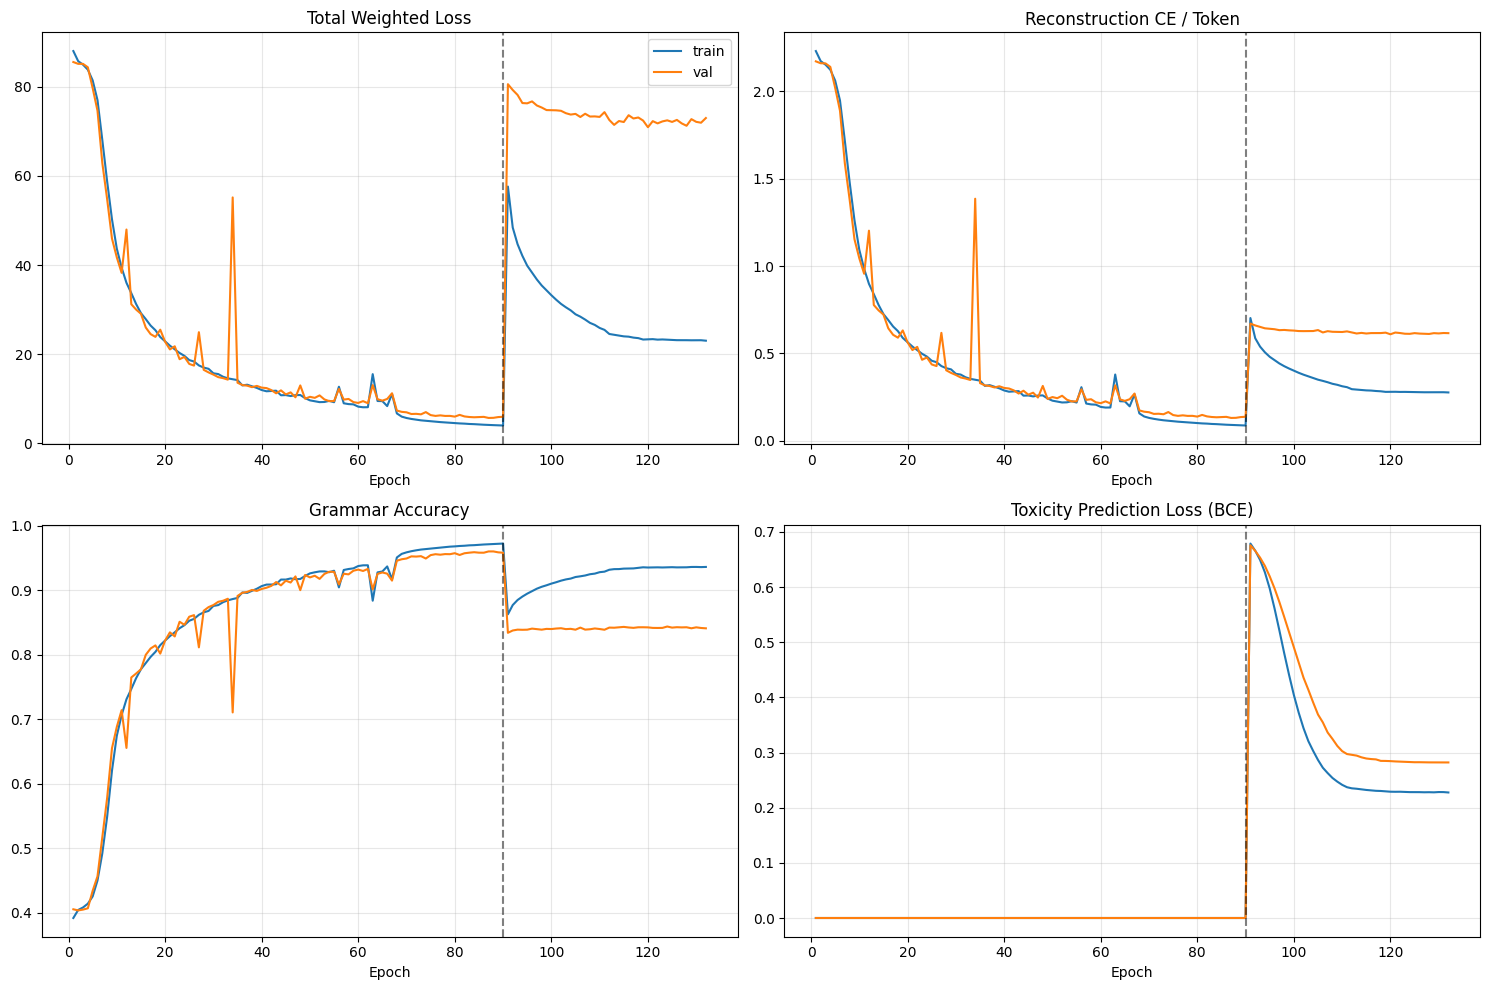

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Helper to safely get history length
# Use 'train_total' as the anchor since it should always exist if training ran
all_keys = history.keys()
max_len = len(history["train_total"]) if "train_total" in history else 0
epochs = np.arange(1, max_len + 1)

if max_len == 0:
    print("Error: History is empty. Check if your train_model function is returning data.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()

    # Define the metrics we want to plot
    # Format: (Key in history, Title, Axis Index)
    metrics_to_plot = [
        ("train_total", "val_total", "Total Weighted Loss", 0),
        ("train_recon_per_token", "val_recon_per_token", "Reconstruction CE / Token", 1),
        ("train_token_acc", "val_token_acc", "Grammar Accuracy", 2),
        ("train_bce", "val_bce", "Toxicity Prediction Loss (BCE)", 3)
    ]

    for train_key, val_key, title, ax_idx in metrics_to_plot:
        ax = axes[ax_idx]
        
        # Check if the keys exist and have data
        train_data = history.get(train_key, [])
        val_data = history.get(val_key, [])
        
        if len(train_data) == max_len:
            ax.plot(epochs, train_data, label="train")
        if len(val_data) == max_len:
            ax.plot(epochs, val_data, label="val")
            
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.grid(True, alpha=0.3)
        if ax_idx == 0: ax.legend()
        
        # Add the Phase 2 divider
        if max_len > PHASE1_EPOCHS:
            ax.axvline(x=PHASE1_EPOCHS, color='black', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

### Quick reconstruction check

In [9]:
def decode_ids_to_selfies(ids: np.ndarray | list[int]) -> str:
    toks = []
    for idx in ids:
        tok = IDX_TO_TOKEN[int(idx)]
        if tok == EOS:
            break
        if tok == PAD:
            continue
        toks.append(tok)
    return "".join(toks)


def show_reconstructions(n: int = 5, seed: int = 42):
    model.eval()

    rng = np.random.default_rng(seed)
    k = min(n, len(test_x))
    idxs = rng.choice(len(test_x), size=k, replace=False)

    x_ids = torch.from_numpy(test_x[idxs]).long().to(device)
    x_onehot = ids_to_onehot(x_ids, VOCAB_SIZE)

    with torch.no_grad():
        logits, _, _ = model(x_onehot)
        pred_ids = logits.argmax(dim=-1).cpu().numpy()

    for j, idx in enumerate(idxs):
        orig_selfies = test_selfies[idx]
        pred_selfies = decode_ids_to_selfies(pred_ids[j])
        exact = orig_selfies == pred_selfies
        print(f"[{j}] exact={exact}")
        print("orig:", orig_selfies)
        print("pred:", pred_selfies)
        print()


show_reconstructions(n=5, seed=SEED)


[0] exact=False
orig: [N][N][C][=Branch1][C][=O][C][C][=N][N][=C][Branch1][C][N][S][Ring1][=Branch1]
pred: [C][N][C][=Branch1][C][=O][C][C][=N][N][=C][Branch1][C][N][=N][Ring1][=Branch1]

[1] exact=False
orig: [C][C][=C][C][=C][C][Branch1][C][C][=C][Ring1][#Branch1][C][=C][C][Branch1][C][C][=C][N][=C][Branch2][Ring1][=Branch1][N][C][=C][C][=C][Branch1][O][O][C][C][N][C][C][C][C][Ring1][Branch1][C][=C][Ring1][=C][N][=N][C][Ring2][Ring1][Branch1][=C][Ring2][Ring1][#Branch2]
pred: [C][C][=C][C][=C][C][Branch1][C][C][=C][Ring1][#Branch1][C][=C][C][Branch1][C][C][=C][N][=C][Branch2][Ring1][=Branch1][N][C][=C][C][=C][Branch1][O][O][C][C][N][C][C][C][C][Ring1][Branch1][C][=C][Ring1][P][C][NH1][C][Ring2][Ring1][Branch1][=C][Ring2][Ring1][#Branch2]

[2] exact=True
orig: [C][C][=N][C][Branch2][Ring1][Ring1][C][=Branch1][C][=O][N][C][C@@H1][Branch1][C][C][C][C@H1][Branch1][C][NH3+1][C][Ring1][Branch2][=C][S][Ring1][#C]
pred: [C][C][=N][C][Branch2][Ring1][Ring1][C][=Branch1][C][=O][N][C][C@@H1][Br

### Notes for downstream tox21 classification
- The best checkpoint is selected using **validation token accuracy** (`*_best.pt`).
- The latest checkpoint (`*_last.pt`) is updated every epoch and contains optimizer/scheduler/history state for crash recovery.

### Crash-resume behavior
With `AUTO_RESUME=True`, the main training cell above will resume automatically from `*_last.pt` if present.

# Tox21 downstream evaluation

## XGBoost on tox21 latent features (train on tox21 train, report val/test AUROC + AUPRC)

In [11]:
def get_model_predictions(model, x_ids, batch_size=512):
    model.eval()
    all_probs = []
    
    # Ensure we are using the correct device
    device = next(model.parameters()).device
    
    with torch.no_grad():
        for i in range(0, len(x_ids), batch_size):
            # 1. Prepare the batch
            xb = torch.from_numpy(x_ids[i:i + batch_size]).long().to(device)
            
            # 2. Forward pass 
            # Note: Using your VAE architecture outputs: logits, mu, logvar, pred
            _, _, _, logits_pred = model(xb)
            
            # 3. Convert raw logits to probabilities (0 to 1)
            probs = torch.sigmoid(logits_pred)
            all_probs.append(probs.cpu().numpy())
            
    return np.vstack(all_probs)

# --- RUN PREDICTIONS ---
# Using the variable names from your Experiment Control block:
P_val_all = get_model_predictions(model, ft_val_x) 
P_test_all = get_model_predictions(model, ft_test_x)

print(f"Generated predictions for Val: {P_val_all.shape} and Test: {P_test_all.shape}")

Generated predictions for Val: (770, 12) and Test: (765, 12)


In [12]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
)


TASKS = [c for c in pd.read_csv(TOX21_TRAIN_PATH, nrows=1).columns if c.startswith("NR-") or c.startswith("SR-")]


def _smiles_to_ids_for_vocab(smiles: str):
    try:
        s = sf.encoder(smiles)
        toks = list(sf.split_selfies(s))
    except Exception:
        return None

    if len(toks) > MAX_LEN:
        return None

    ids = [TOKEN_TO_IDX.get(tok, UNK_IDX) for tok in toks[:MAX_LEN]]
    ids.append(EOS_IDX)

    arr = np.full(SEQ_LEN, PAD_IDX, dtype=np.int64)
    arr[:len(ids)] = ids
    return arr

In [13]:
# ==========================================
# INTERNAL PREDICTOR HEAD EVALUATION
# ==========================================

# --- AUTO-ADAPT VARIABLE NAMES ---
# This ensures the code works regardless of whether you used 'ft' suffixes or not
Y_val_eval = y_val_ft.detach().cpu().numpy() if torch.is_tensor(y_val_ft) else y_val_ft
Y_test_eval = y_test_ft.detach().cpu().numpy() if torch.is_tensor(y_test_ft) else y_test_ft

# Ensure P_val_all and P_test_all are available from your prediction step
# If you haven't run get_model_predictions() yet, make sure to do that first!

def _binary_metrics(y_true: np.ndarray, probs: np.ndarray, threshold: float) -> dict:
    y_true = y_true.astype(int)
    y_hat = (probs >= threshold).astype(int)

    out = {
        "n": int(len(y_true)),
        "Accuracy": float(accuracy_score(y_true, y_hat)) if len(y_true) else np.nan,
        "F1": float(f1_score(y_true, y_hat, zero_division=0)) if len(y_true) else np.nan,
        "Precision": float(precision_score(y_true, y_hat, zero_division=0)) if len(y_true) else np.nan,
        "Recall": float(recall_score(y_true, y_hat, zero_division=0)) if len(y_true) else np.nan,
        "AUROC": np.nan,
        "AUPRC": np.nan,
    }

    if len(y_true) and len(np.unique(y_true)) >= 2:
        out["AUROC"] = float(roc_auc_score(y_true, probs))
        out["AUPRC"] = float(average_precision_score(y_true, probs))

    return out

task_rows = []
roc_curves = {}
pr_curves = {}

# loop through each task (e.g., NR-AR, SR-ARE)
for j, task in enumerate(TASKS):
    # Slice the ground truth and the model probabilities for this specific task
    yv, yt = Y_val_eval[:, j], Y_test_eval[:, j]
    pv_task, pt_task = P_val_all[:, j], P_test_all[:, j]

    # Filter for valid labels (0 or 1, ignore NaNs/unlabeled markers like -1)
    mv = np.isin(yv, [0, 1])
    mt = np.isin(yt, [0, 1])

    # Skip task if no valid samples or only one class represented in validation
    if int(mv.sum()) == 0 or len(np.unique(yv[mv])) < 2:
        continue

    # 1. Find best threshold on Validation set (tuning for F1 score)
    thresholds = np.linspace(0.05, 0.95, 19)
    y_val_clean = yv[mv].astype(int)
    p_val_clean = pv_task[mv]
    
    best_t = max(
        thresholds,
        key=lambda t: f1_score(y_val_clean, (p_val_clean >= t).astype(int), zero_division=0),
    )

    # 2. Extract Test set metrics using the best threshold found above
    y_test_clean = yt[mt].astype(int)
    p_test_clean = pt_task[mt]

    val_res = _binary_metrics(y_val_clean, p_val_clean, best_t)
    test_res = _binary_metrics(y_test_clean, p_test_clean, best_t)

    task_rows.append({
        "task": task,
        "threshold": float(best_t),
        "n_test": int(test_res["n"]),
        "Test_AUROC": test_res["AUROC"],
        "Test_AUPRC": test_res["AUPRC"],
        "Test_F1": test_res["F1"],
        "Test_Accuracy": test_res["Accuracy"]
    })

    # 3. Store curves for plotting
    if not np.isnan(test_res["AUROC"]):
        fpr, tpr, _ = roc_curve(y_test_clean, p_test_clean)
        prec, rec, _ = precision_recall_curve(y_test_clean, p_test_clean)
        roc_curves[task] = (fpr, tpr, float(test_res["AUROC"]))
        pr_curves[task] = (rec, prec, float(test_res["AUPRC"]), float(y_test_clean.mean()))

# --- DISPLAY RESULTS ---
if task_rows:
    pred_head_metrics_df = pd.DataFrame(task_rows).sort_values("Test_AUROC", ascending=False)
    display(pred_head_metrics_df)
    
    print("\nMacro Averages across all valid tasks:")
    print(pred_head_metrics_df[["Test_AUROC", "Test_AUPRC", "Test_F1", "Test_Accuracy"]].mean())
else:
    print(">>> No tasks had sufficient data/variation for evaluation.")

,task,threshold,n_test,Test_AUROC,Test_AUPRC,Test_F1,Test_Accuracy
2,NR-AhR,0.05,765,0.550354,0.182026,0.209246,0.150327
4,NR-ER,0.05,765,0.536608,0.122869,0.162362,0.109804
8,SR-ATAD5,0.05,765,0.518381,0.065905,0.086438,0.198693
11,SR-p53,0.05,765,0.514851,0.107270,0.165088,0.193464
0,NR-AR,0.10,765,0.511342,0.045330,0.073684,0.309804
10,SR-MMP,0.15,765,0.498910,0.126237,0.208723,0.335948
7,SR-ARE,0.15,765,0.488612,0.144229,0.240469,0.322876
3,NR-Aromatase,0.05,765,0.466544,0.060898,0.097282,0.175163
9,SR-HSE,0.15,765,0.465033,0.061457,0.104987,0.554248
6,NR-PPAR-gamma,0.05,765,0.419430,0.024960,0.052308,0.194771



Macro Averages across all valid tasks:
Test_AUROC       0.481828
Test_AUPRC       0.082296
Test_F1          0.124892
Test_Accuracy    0.239434
dtype: float64


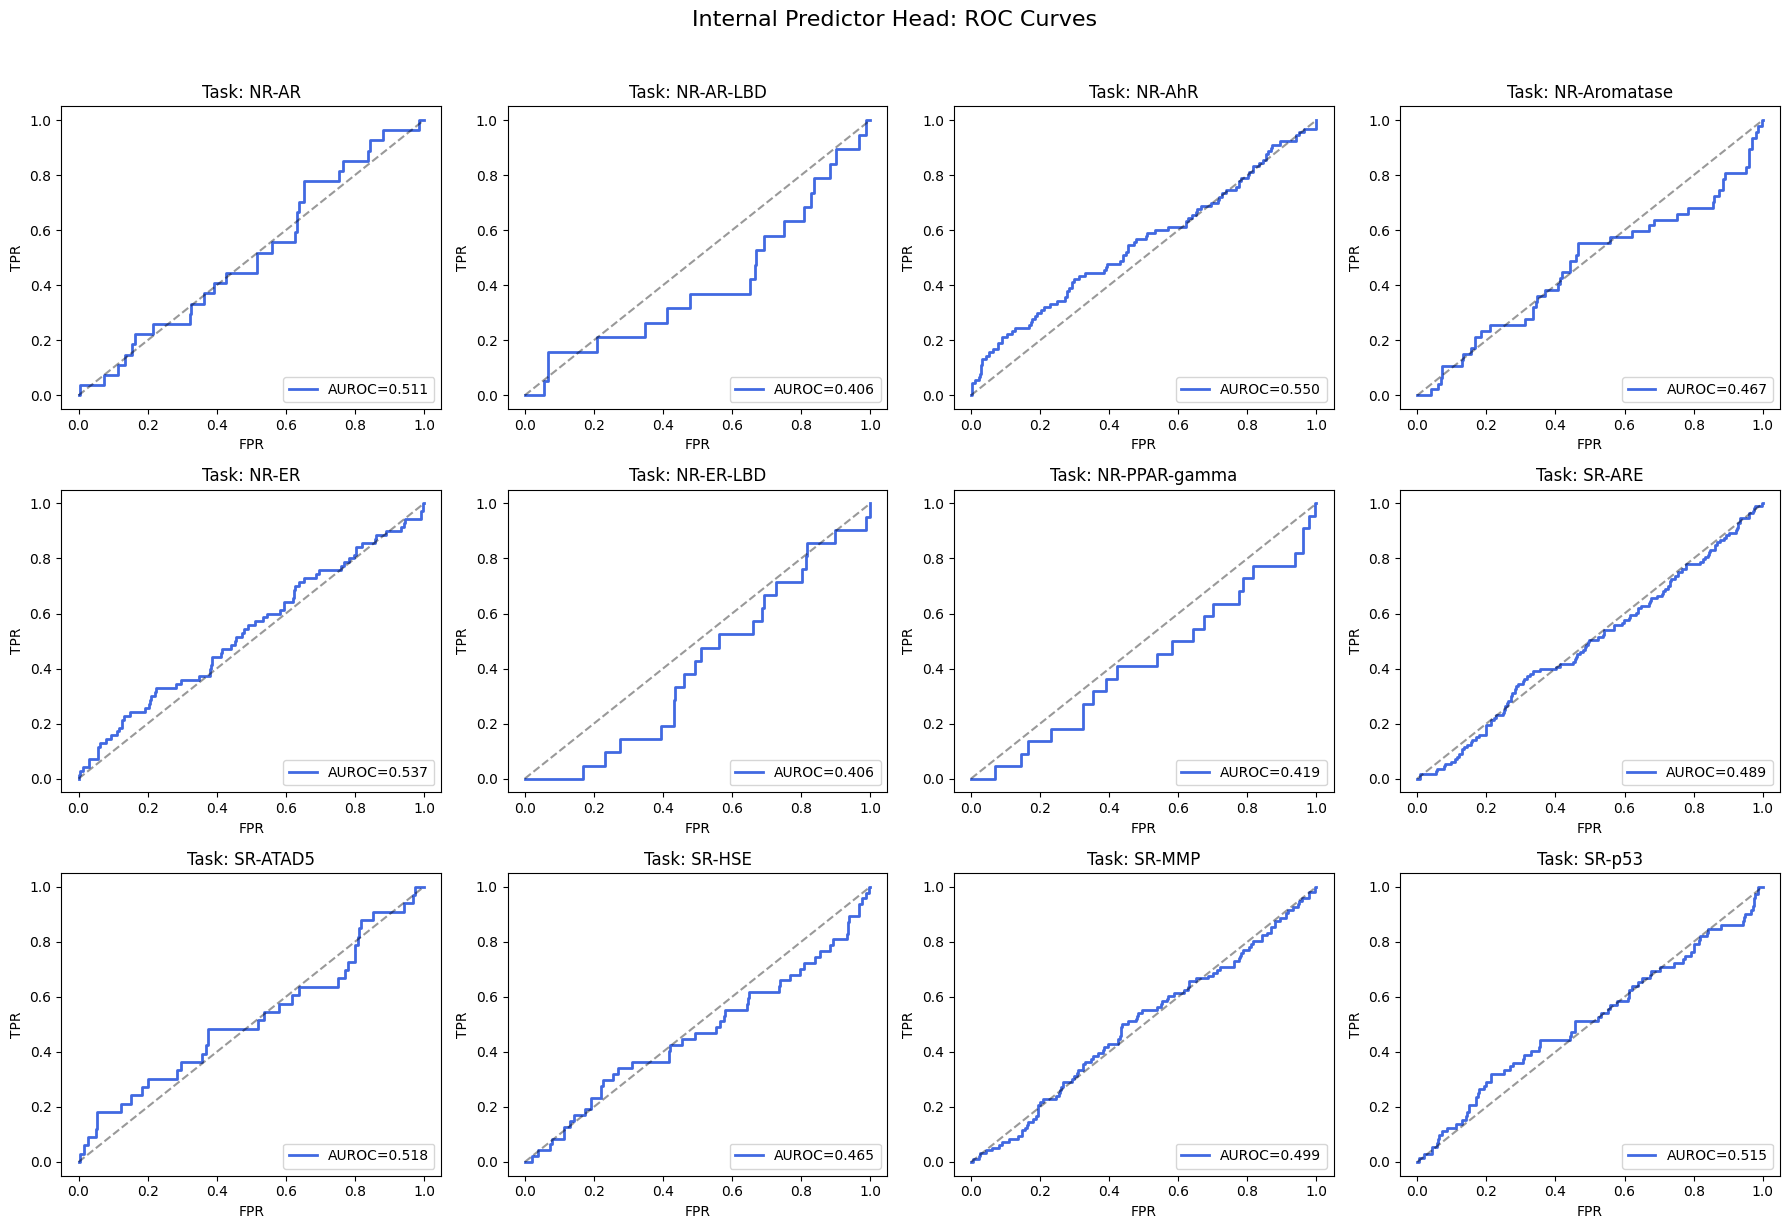

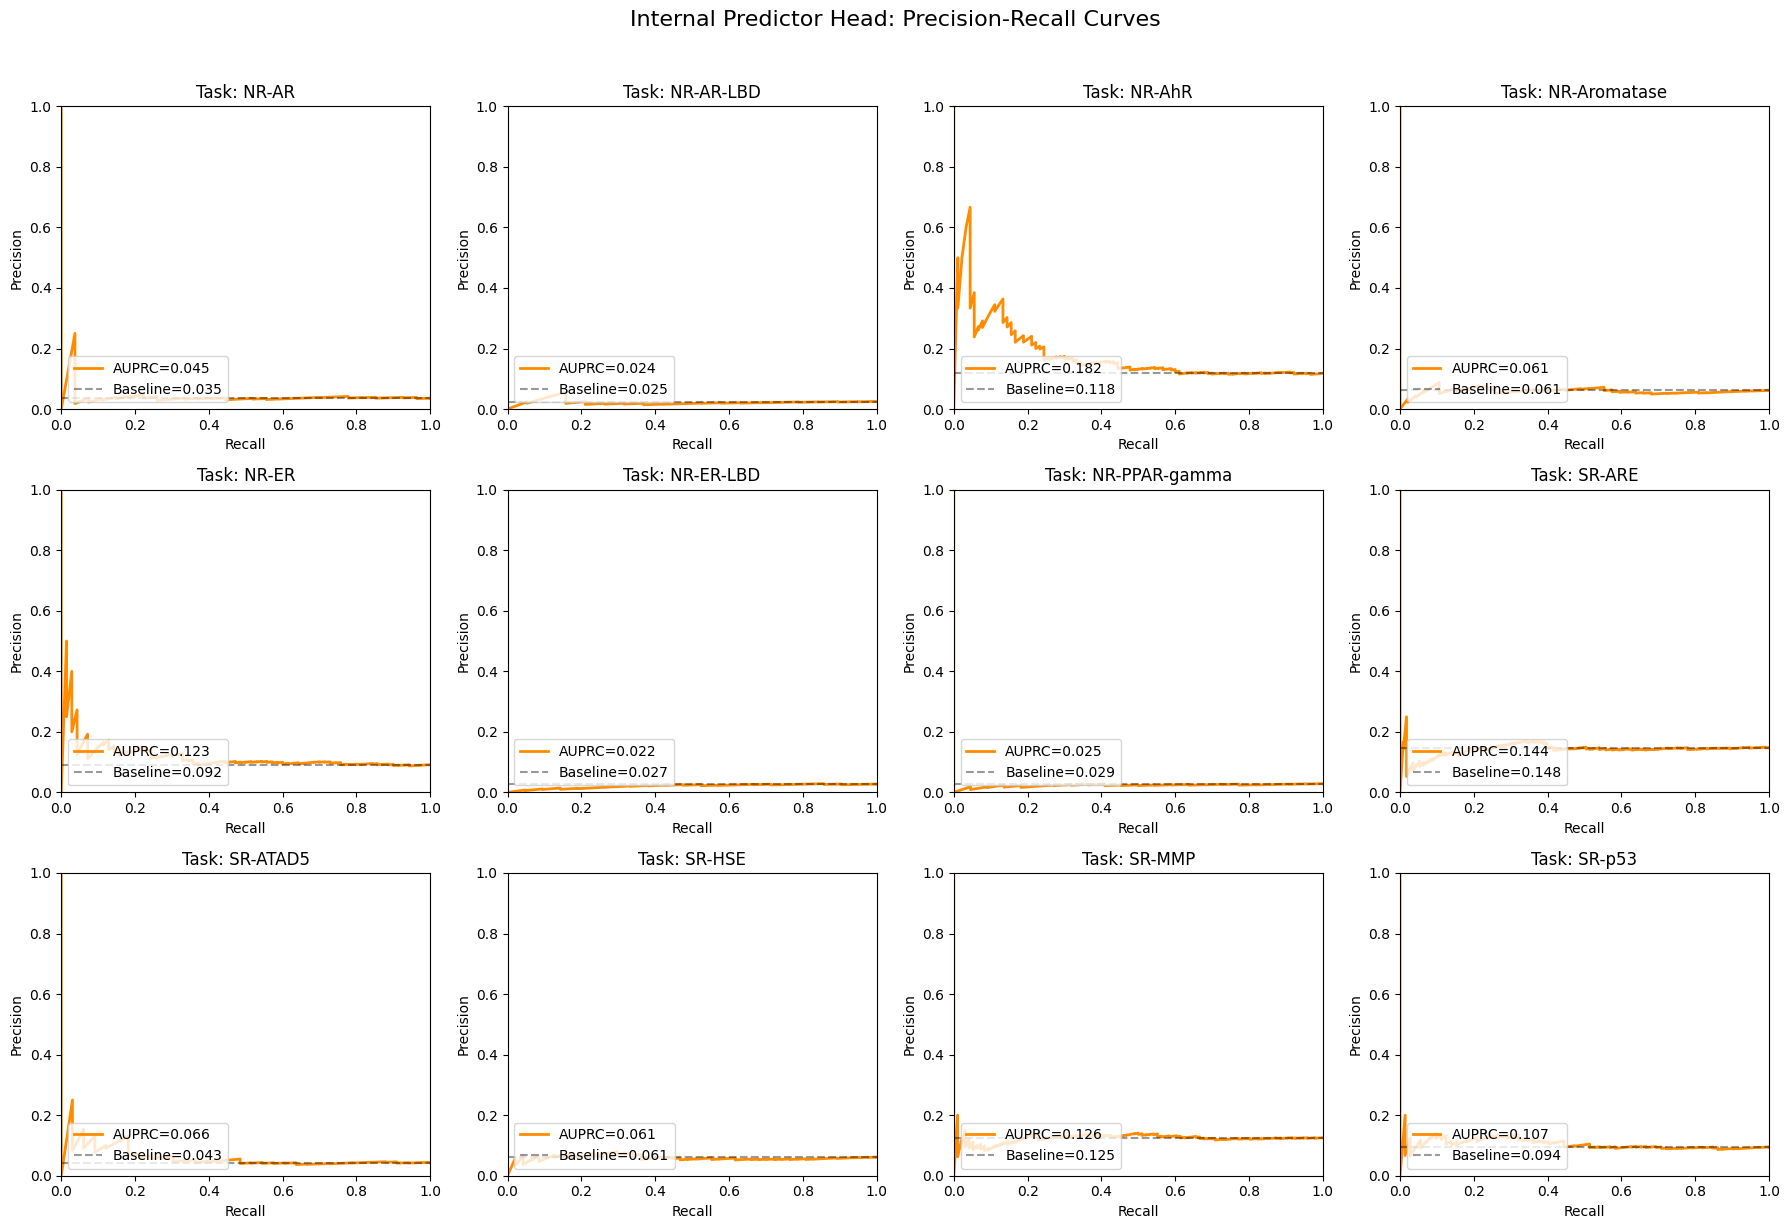

In [14]:
# --- 1. AUROC PLOTS ---
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle("Internal Predictor Head: ROC Curves", fontsize=16, y=1.02)

for ax, task in zip(axes.ravel(), TASKS):
    if task in roc_curves:
        fpr, tpr, auc = roc_curves[task]
        ax.plot(fpr, tpr, color='royalblue', lw=2, label=f"AUROC={auc:.3f}")
        ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
        ax.set_title(f"Task: {task}")
        ax.set_xlabel("FPR")
        ax.set_ylabel("TPR")
        ax.legend(loc="lower right")
    else:
        ax.set_title(task)
        ax.text(0.5, 0.5, "Insufficient Variation\nor Task Skipped", 
                ha="center", va="center", color='gray')
        ax.axis("off")

plt.tight_layout()
plt.show()

# --- 2. AUPRC PLOTS ---
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle("Internal Predictor Head: Precision-Recall Curves", fontsize=16, y=1.02)

for ax, task in zip(axes.ravel(), TASKS):
    if task in pr_curves:
        rec, prec, ap, base = pr_curves[task]
        ax.plot(rec, prec, color='darkorange', lw=2, label=f"AUPRC={ap:.3f}")
        # Baseline is the proportion of positive samples in the test set
        ax.hlines(base, 0, 1, colors="k", linestyles="--", alpha=0.4, label=f"Baseline={base:.3f}")
        ax.set_title(f"Task: {task}")
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.legend(loc="lower left")
    else:
        ax.set_title(task)
        ax.text(0.5, 0.5, "Insufficient Variation\nor Task Skipped", 
                ha="center", va="center", color='gray')
        ax.axis("off")

plt.tight_layout()
plt.show()